In [1]:
!pip install transformers timm --quiet

import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

In [2]:
# Load secret
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

# Login to HuggingFace
login(token=hf_token)

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
MODEL_PATH = "SARVM/ViT_Deepfake"

model = ViTForImageClassification.from_pretrained(
    MODEL_PATH,
    output_attentions=True
)

processor = ViTImageProcessor.from_pretrained(MODEL_PATH)

model.to(DEVICE)
model.eval()

print("Model loaded successfully")

config.json:   0%|          | 0.00/556 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

Model loaded successfully


In [5]:
def attention_rollout(attentions):
    """
    Perform Attention Rollout for ViT
    attentions: tuple of attention tensors from each layer
    """

    # Stack attentions
    result = torch.eye(attentions[0].size(-1)).to(DEVICE)

    for attention in attentions:
        # Average heads
        attn_heads_fused = attention.mean(dim=1)

        # Add identity (skip connection)
        identity = torch.eye(attn_heads_fused.size(-1)).to(DEVICE)
        attn_heads_fused = attn_heads_fused + identity

        # Normalize
        attn_heads_fused = attn_heads_fused / attn_heads_fused.sum(dim=-1, keepdim=True)

        # Multiply
        result = torch.matmul(attn_heads_fused, result)

    return result

In [28]:
def generate_attention_map(image_path):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(DEVICE)

    with torch.no_grad():
        outputs = model(pixel_values)

    logits = outputs.logits
    probs = F.softmax(logits, dim=1)
    confidence, pred_class = torch.max(probs, dim=1)

    pred_class = pred_class.item()
    confidence = confidence.item()

    attentions = outputs.attentions

    rollout = attention_rollout(attentions)

    # Remove CLS token
    mask = rollout[0, 0, 1:]

    # Reshape to 14x14 (ViT base patch16-224 → 14x14 patches)
    mask = mask.reshape(14, 14).detach().cpu().numpy()

    # Normalize
    mask = (mask - mask.min()) / (mask.max() - mask.min())

    # Resize to image size
    mask = cv2.resize(mask, image.size)

    heatmap = cv2.applyColorMap(
        np.uint8(255 * mask),
        cv2.COLORMAP_JET
    )

    original_np = np.array(image)

    # 🔥 Highlight only if FAKE (class 0)
    if pred_class == 0:
        overlay = cv2.addWeighted(original_np, 0.6, heatmap, 0.4, 0)
        explanation = "Model detected manipulated facial regions."
        label = "FAKE"
    else:
        overlay = original_np
        explanation = "No manipulation patterns detected."
        label = "REAL"

    # Plot
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(original_np)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.4f}")
    plt.axis("off")

    plt.show()

    print("Explanation:", explanation)

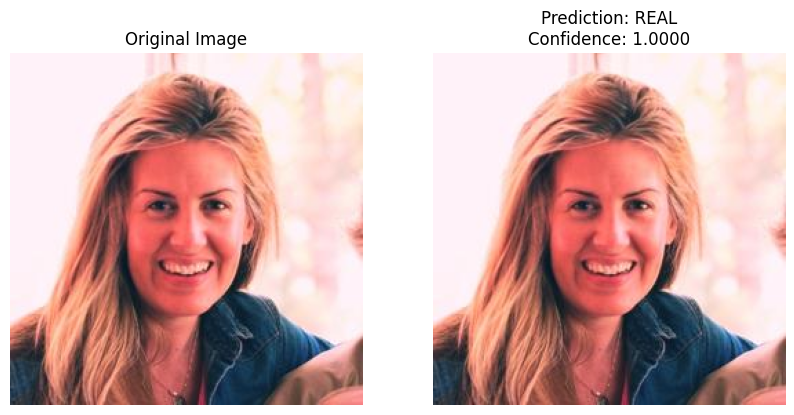

Explanation: No manipulation patterns detected.


In [31]:
image_path = "/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Test/Real/real_1043.jpg"

generate_attention_map(image_path)

In [ ]:
image_path = "/kaggle/input/datasets/puttavenkatasai/messi10/WhatsApp Image 2026-02-27 at 2.44.51 PM.jpeg"

generate_attention_map(image_path)

In [ ]:
image_path = "/kaggle/input/datasets/puttavenkatasai/messi10/WhatsApp Image 2026-02-27 at 2.44.50 PM (2).jpeg"

generate_attention_map(image_path)

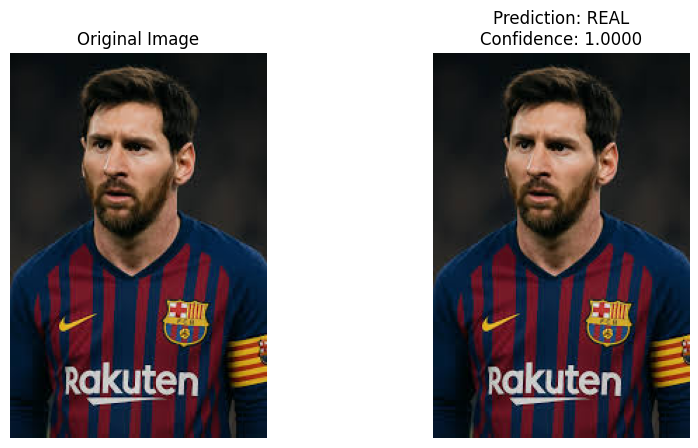

Explanation: No manipulation patterns detected.


In [29]:
image_path = "/kaggle/input/datasets/puttavenkatasai/messi10/test.jpg"

generate_attention_map(image_path)

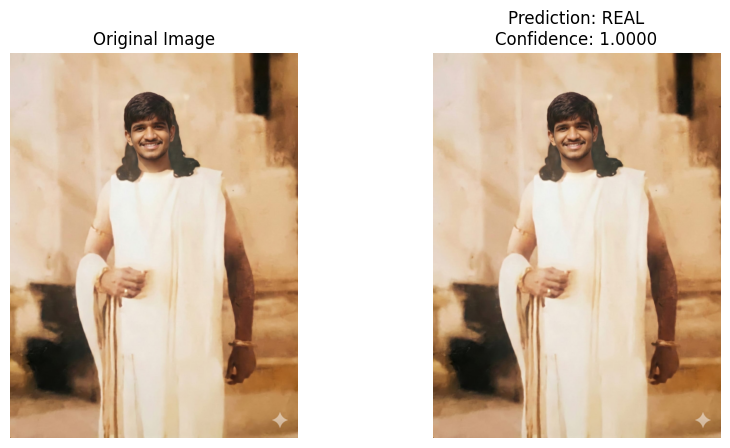

Explanation: No manipulation patterns detected.


In [38]:
image_path = "/kaggle/input/datasets/puttavenkatasai/messi10/WhatsApp Image 2026-02-27 at 3.16.53 PM (1).jpeg"

generate_attention_map(image_path)